In [2]:
# XGBoost Model for Customer Churn Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("synthetic_customer_churn_100k.csv")

# Drop unnecessary columns
df.drop("CustomerID", axis=1, inplace=True)

# Encode categorical columns
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.75975

Confusion Matrix:
[[11444  1850]
 [ 2955  3751]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.83     13294
           1       0.67      0.56      0.61      6706

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.75      0.76      0.75     20000



c:\Users\Asus\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:39:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


NameError: name 'plt' is not defined

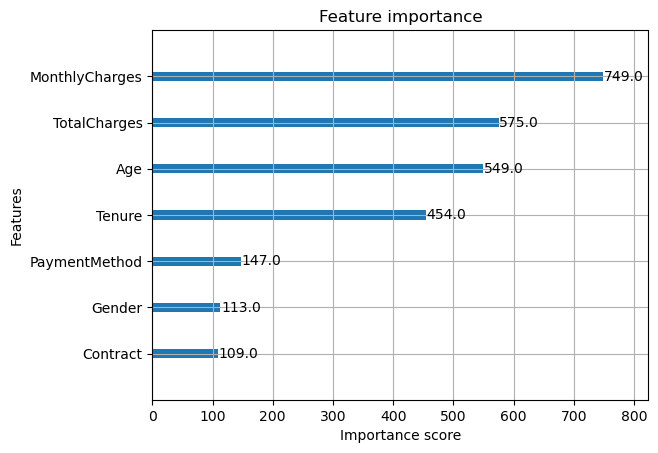

In [3]:
import xgboost as xgb

xgb.plot_importance(xgb_model)
plt.show()